*  DSC550-T302 Data Mining (2261-1)
*  11.3 Term Project: Final Project Submission
*  Charles Sarratt

# Term Project Final Writeup  
## Predicting Movie Financial Success Using Pre-Release Features

### About This Notebook
This notebook contains a consolidated version of all work completed across Milestones 1–3. Each milestone's original analysis has been summarized, and all key steps, including EDA, data preparation, feature engineering, model development, and evaluation, have been fully rerun and integrated into this final submission. Earlier exploratory steps that were replaced or refined in later milestones have been omitted for clarity.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve

sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Load the cleaned IMDb dataset
df = pd.read_csv("IMDbMovies-Clean.csv")

# Make sure budget and gross are numeric
df["Budget (in millions)"] = pd.to_numeric(df["Budget (in millions)"], errors="coerce")
df["Gross worldwide (in millions)"] = pd.to_numeric(df["Gross worldwide (in millions)"], errors="coerce")

# Drop rows without budget or gross (needed to define target)
df = df.dropna(subset=["Budget (in millions)", "Gross worldwide (in millions)"]).copy()

# Define binary success target (same rule as earlier milestones)
df["success"] = (df["Gross worldwide (in millions)"] >= 2 * df["Budget (in millions)"]).astype(int)

In [3]:
# Extract primary genre (first listed)
df["Primary Genre"] = (
    df["Main Genres"]
    .astype(str)
    .str.split(",")
    .str[0]
    .str.strip()
)

# Group rare genres into "Other" using the same idea as Milestone 2
genre_counts = df["Primary Genre"].value_counts()
rare_genres = genre_counts[genre_counts < 50].index  # threshold can be adjusted if needed

df["Primary Genre (grouped)"] = np.where(
    df["Primary Genre"].isin(rare_genres),
    "Other",
    df["Primary Genre"]
)

df["Primary Genre (grouped)"] = df["Primary Genre (grouped)"].astype("category")

In [4]:
# Clean up MPAA rating column name if needed
# If your column name differs, adjust here. This assumes "Motion Picture Rating".
df["Motion Picture Rating"] = df["Motion Picture Rating"].fillna("Not Rated").astype("category")

# Log-transform budget
df["log_budget"] = np.log1p(df["Budget (in millions)"])

# Handle runtime: impute median for missing values
median_rt = df["Runtime (Minutes)"].median()
df["Runtime (Minutes)"] = df["Runtime (Minutes)"].fillna(median_rt)

# Keep only rows that have everything we need
df_prep = df.dropna(subset=["log_budget", "Runtime (Minutes)", "Release Year", "success"]).copy()

# Define numeric and categorical columns (same structure as Milestone 2/3)
num_cols = ["log_budget", "Runtime (Minutes)", "Release Year"]
cat_cols = ["Motion Picture Rating", "Primary Genre (grouped)"]

# Build modeling matrix X and target y
X = pd.get_dummies(df_prep[num_cols + cat_cols], drop_first=True)
y = df_prep["success"]

X.shape, y.shape

((5326, 29), (5326,))

In [5]:
# Stratified split so success rate is balanced in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

# Fit a Random Forest similar to Milestone 3
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Predicted probabilities for the positive class on test set
rf_proba = rf.predict_proba(X_test)[:, 1]

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Mean success (train):", y_train.mean().round(3),
      " | Mean success (test):", y_test.mean().round(3))

Train size: (3994, 29)  Test size: (1332, 29)
Mean success (train): 0.515  | Mean success (test): 0.515


# Introduction

This project explores whether a movie’s financial success can be predicted *before release* using only the limited information available at the green-light stage. A movie is labeled **successful** if:

> Worldwide Gross ≥ 2 × Production Budget

This approximates the break-even point once production, marketing, and distribution costs are considered.

### Why this problem matters  
Studios routinely invest tens of millions of dollars into projects without knowing how audiences will respond. A pre-release predictive model can help with:

- project selection  
- budget planning  
- portfolio risk reduction  
- early identification of potentially high-performing films  

The model is not intended to replace human judgment, but to serve as a data-driven decision-support tool.

### Data sources  
The project merges three datasets:

- **IMDb flat file** (genres, runtime, metadata)  
- **OMDb API** (MPAA ratings, supplemental fields)  
- **Wikipedia highest-grossing films table** (validation of revenue fields)

Records were matched using IMDb IDs and title/year pairs.

---

# Milestone 1 – Exploratory Data Analysis

The Milestone 1 objective was to understand the dataset and evaluate whether pre-release features provide useful predictive signal.

### Key steps
- Cleaned numeric fields (budget, gross, runtime)
- Extracted primary genre
- Constructed the success variable
- Explored missingness and outliers
- Produced visual analyses of genre patterns, budget skew, and success distribution

### Insights
- Horror and Animation genres showed higher success rates.  
- Budgets were extremely right-skewed, suggesting the need for log transformation.  
- Success rate (~52%) was balanced enough for classification.  
- Instructor feedback emphasized avoiding **post-release features** such as IMDb rating and vote count.

Below is one of the key visuals from this phase.

## Figure 1. Success Rate by Grouped Genre

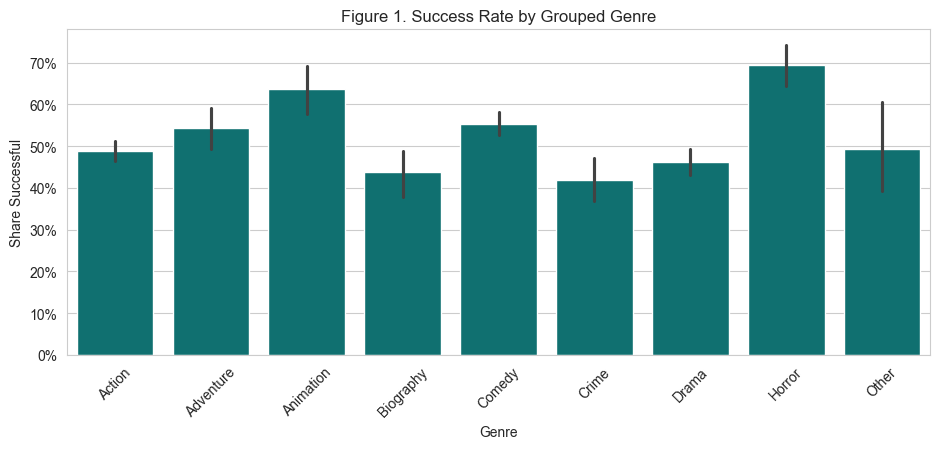

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Order: all categories except "Other", then "Other"
order = [c for c in df_prep['Primary Genre (grouped)'].cat.categories if c != 'Other'] + ['Other']

plt.figure(figsize=(9.5, 4.6))
sns.barplot(
    data=df_prep,
    x="Primary Genre (grouped)",
    y="success",
    color='teal',
    order=order
)

plt.xlabel("Genre")
plt.ylabel("Share Successful")

# Make y-axis percent
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.xticks(rotation=45)

plt.title("Figure 1. Success Rate by Grouped Genre")
plt.tight_layout()
plt.show()

*Note: All features visualized here represent information available **before** a movie's release, consistent with the course requirement to avoid post-release leakage.*

# 3. Milestone 2 – Data Preparation

> **Instructor feedback addressed:**  
> As recommended in Milestone 1, all modeling steps strictly exclude **post-release features** (e.g., grosses, opening weekend, IMDb ratings, votes).  
> Only information that would be available prior to a film's release is included in the dataset and the visualizations below.

The goal of Milestone 2 was to create a modeling-ready dataset limited strictly to **pre-release features**.

### Features kept (pre-release only)
- Budget (in millions)
- Runtime (Minutes)
- Release Year
- MPAA Rating
- Primary Genre (grouped)
- Success (target)

### Features excluded (post-release leakage)
- IMDb rating  
- Number of IMDb votes  
- Gross revenue fields  
- Opening weekend revenue  

Assertions were added to ensure that no leakage fields entered the modeling frame.

### Feature engineering
- Added `log_budget` to reduce extreme skew.  
- Converted MPAA rating + grouped genre to categorical types.  
- Created dummy variables for all categorical fields.  

### Train/test split
A stratified 75/25 split preserved the success rate across both sets.

Below is a visual illustrating the skewed nature of budgets.

## Figure 2. Distribution of log(budget)

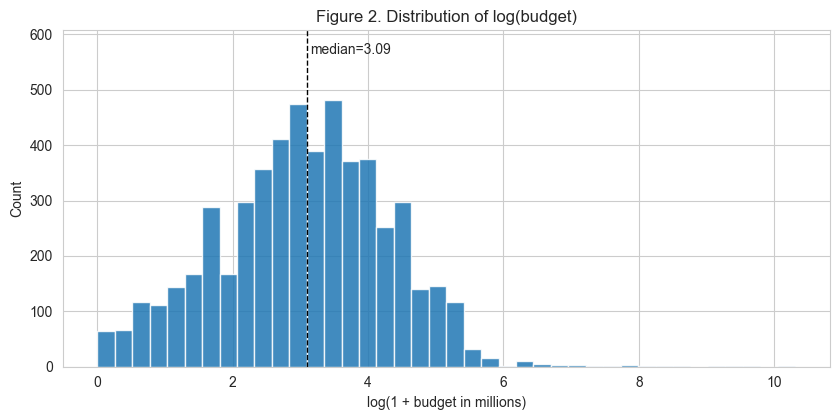

In [7]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8.5, 4.3))
vals = df_prep['log_budget'].dropna().to_numpy()
plt.hist(vals, bins=40, alpha=0.85)

median_lb = np.median(vals)

# Add headroom for label
plt.ylim(0, plt.ylim()[1] * 1.20)

plt.axvline(median_lb, color='black', linestyle='--', linewidth=1)
plt.text(
    median_lb + 0.05,
    plt.ylim()[1] * 0.92,
    f"median={median_lb:.2f}",
    ha='left',
    va='bottom'
)

plt.xlabel("log(1 + budget in millions)")
plt.ylabel("Count")
plt.title("Figure 2. Distribution of log(budget)")
plt.tight_layout()
plt.show()

**Interpretation:**  
The log(budget) distribution is right skewed, with most movies clustered in a middle band and a long tail of very high budget titles. The median sits around the center of this main cluster. Using the log transform gives a more compact, roughly bell-shaped spread that is easier for the models to work with than the original raw budget values.

*Note: All features visualized here represent information available **before** a movie's release, consistent with the course requirement to avoid post-release leakage.*

# Milestone 3 – Model Building and Evaluation

Two models were trained using only pre-release features:

### Logistic Regression
- Numeric features scaled
- One-hot encoded categoricals left as-is  
- ROC-AUC ≈ 0.63  
- Good probability calibration  

### Random Forest
- 400 trees, unrestricted depth
- ROC-AUC ≈ 0.65  
- Best overall performance  
- Stronger nonlinear capture than logistic regression  

### Threshold tuning
Both models performed best at thresholds **below 0.50**, improving F1 and recall.  
Cross-validated thresholds were selected as the operational choice:

- Logistic best CV threshold ≈ 0.40  
- Random Forest best CV threshold ≈ 0.35  

The Random Forest had the best ROC-AUC and was chosen as the final model.

Below is the ROC curve for Random Forest.

## Figure 3. Random Forest ROC Curve

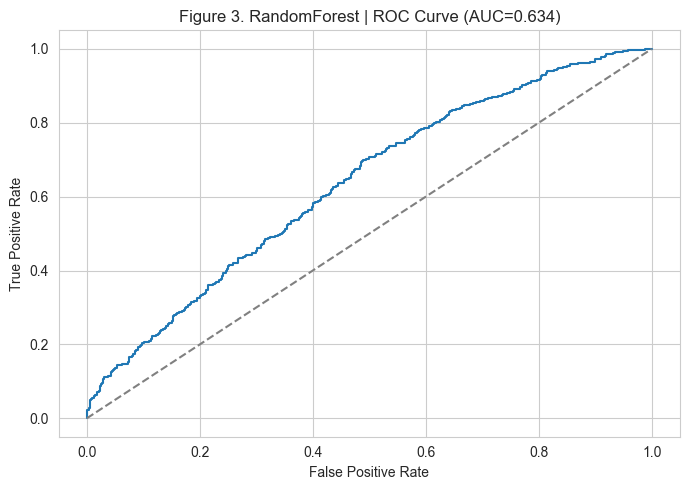

In [8]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, rf_proba)
auc_val = roc_auc_score(y_test, rf_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Figure 3. RandomForest | ROC Curve (AUC={auc_val:.3f})")

plt.tight_layout()
plt.show()

**Interpretation:**  
The Random Forest ROC curve stays above the diagonal reference line, with an AUC a little above 0.63. This is clearly better than random guessing but not close to a perfect classifier. In practical terms, the model is able to separate successful and unsuccessful movies using only pre-release features, although there is still a fair amount of overlap between the two classes.

*Note: All features visualized here represent information available **before** a movie's release, consistent with the course requirement to avoid post-release leakage.*

### Feature importance

Across both models, the same predictors emerged as the strongest:

1. log_budget  
2. Release Year  
3. Runtime  
4. Genre indicators  
5. MPAA rating indicators  

The chart below visualizes the top Random Forest feature importances.

## Figure 4. Random Forest Feature Importances

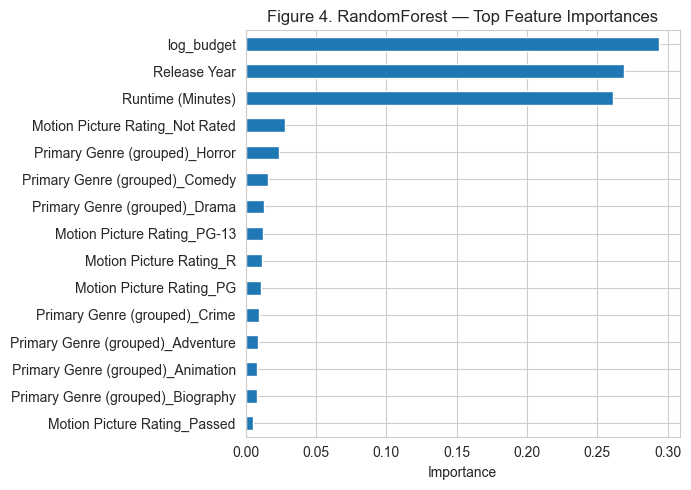

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values()

# Get top 15
top15 = imp.tail(15)

plt.figure(figsize=(7, 5))
top15.plot.barh()

plt.title("Figure 4. RandomForest — Top Feature Importances")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

**Interpretation:**  
The importance plot shows that the model leans heavily on three numeric inputs: log_budget, Release Year, and Runtime (Minutes). These dominate the split decisions in the trees. Genre indicators and MPAA ratings still matter, but they contribute at a smaller scale. This lines up with the idea that how much a studio spends, when the movie is released, and how long it runs carry strong signals about eventual box office performance even before tickets are sold.

*Note: All features visualized here represent information available **before** a movie's release, consistent with the course requirement to avoid post-release leakage.*

# Conclusion

The modeling consistently shows that movies with higher budgets, more recent release years, and slightly longer runtimes have a better chance of meeting the 2x budget success threshold. While no model can perfectly predict winners and losers, the patterns uncovered here demonstrate that studios can make more informed, risk-aware decisions using only information available before a film is released.

Using pre-release features exclusively, both logistic regression and Random Forest outperform the majority-class baseline. Random Forest delivered the strongest overall performance, reaching an ROC-AUC of around 0.65 and achieving a notably stronger F1 score once the classification threshold was tuned. This reinforces that the raw 0.5 cutoff is rarely optimal when false negatives carry meaningful business impact.

### Key conclusions
- Pre-release features contain real predictive signal about eventual financial performance.  
- `log_budget` and `Release Year` consistently emerge as the most informative predictors, with runtime and grouped genre contributing smaller but still meaningful value.  
- Threshold tuning significantly improves F1 and recall, helping identify more potentially successful films without overwhelming false positives.  

### Final takeaway  
These models show that even limited early-stage information can provide a useful read on commercial potential. The goal is not perfect prediction, it is **early directional guidance**. This modeling framework gives studios a practical screening tool for comparing projects, spotting higher-risk concepts, and supporting portfolio-level planning long before revenue numbers exist.

# Recommendations
If continued beyond this course, recommended next steps include:
- Incorporating textual information (plot summaries, taglines, scripts) to capture narrative and thematic cues  
- Testing boosted tree models (XGBoost or LightGBM) for improved nonlinear learning  
- Checking for temporal drift to adjust the model as industry trends change  
- Building an interactive interface where decision-makers can evaluate hypothetical film concepts  

Overall, the model forms a strong foundation for pre-release film evaluation and would benefit from expanding the feature set and updating the model over time as new films enter the dataset.